# Aufgabe 1

Plotten der Position zur Zeit

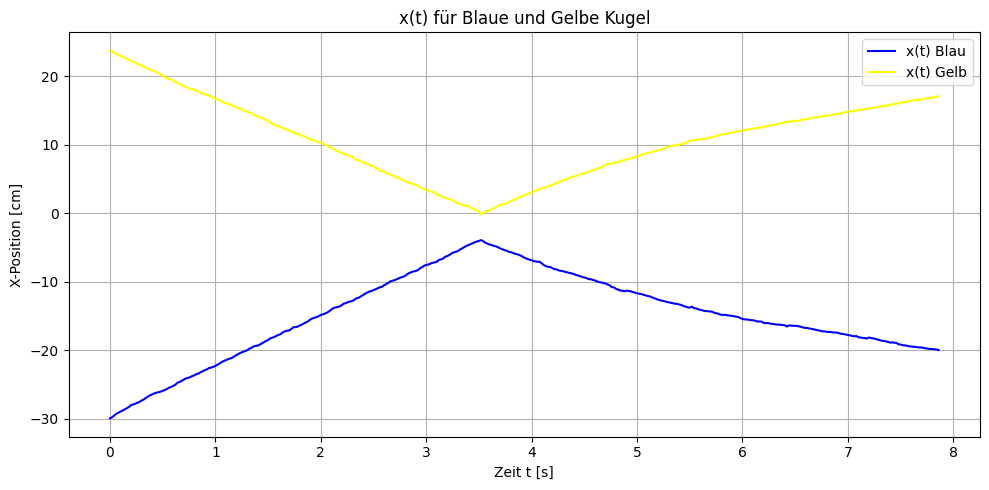

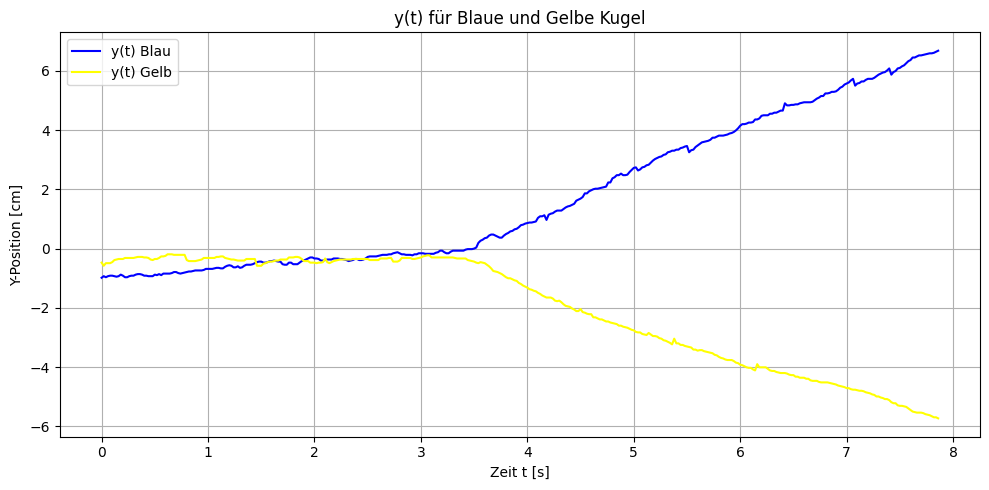

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import os

# a. CSV einlesen & Positionen vs. Zeit plotten
# df_Blau = pd.read_csv('Data_Blaue_Kugel.csv', usecols=[0,1,2])  # nur t, x, y
# df_Blau.columns = ['t', 'x', 'y']
# df_Gelb = pd.read_csv('Data_Gelbe_Kugel.csv', usecols=[0,1,2])  # nur t, x, y
# df_Gelb.columns = ['t', 'x', 'y']

# Zeitpunkte definieren
stoßzeit = 3.52

# Daten Position definieren
Daten_x_Blau = []
Daten_y_Blau = []
Daten_x_Gelb = []
Daten_y_Gelb = []
Daten_t = []


# Ordnerpfad anpassen
filepath = "Aufgabe_1_CSV_Daten"

# Alle CSV-Dateien holen und sortieren
csv_files = [f for f in os.listdir(filepath) if f.endswith('.csv')]

for file in csv_files:
    color = file[5:9]
    df = pd.read_csv(os.path.join(filepath, file), usecols=[0, 1, 2])  # nur t, x, y
    df.columns = ['t', 'x', 'y']
    globals()[f'Daten_x_{color}'] = df['x'].values
    globals()[f'Daten_y_{color}'] = df['y'].values
    globals()[f'Daten_t'] = df['t'].values


# Plot
plt.figure(figsize=(10, 5))
plt.plot(Daten_t, Daten_x_Blau, label='x(t) Blau', color='blue')
plt.plot(Daten_t, Daten_x_Gelb, label='x(t) Gelb', color='yellow')
plt.xlabel('Zeit t [s]')
plt.ylabel('X-Position [cm]')
plt.title('x(t) für Blaue und Gelbe Kugel')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(Daten_t, Daten_y_Blau, label='y(t) Blau', color='blue')
plt.plot(Daten_t, Daten_y_Gelb, label='y(t) Gelb', color='yellow')
plt.xlabel('Zeit t [s]')
plt.ylabel('Y-Position [cm]')
plt.title('y(t) für Blaue und Gelbe Kugel')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
    



# # Daten aufteilen
# df_vor_Blau = df_Blau[df_Blau['t'] <= stoßzeit]
# df_nach_Blau = df_Blau[df_Blau['t'] >= stoßzeit]
# df_vor_Gelb = df_Blau[df_Blau['t'] <= stoßzeit]
# df_nach_Gelb = df_Blau[df_Blau['t'] >= stoßzeit]

# # Lineare Fits durchführen
# # Blaue Kugel
# fit_vor_x_Blau = np.polyfit(df_vor_Blau['t'], df_vor_Blau['x'], 1)   # Grad 1 = lineare Regression
# fit_nach_x_Blau = np.polyfit(df_nach_Blau['t'], df_nach_Blau['x'], 1)
# fit_vor_y_Blau = np.polyfit(df_vor_Blau['t'], df_vor_Blau['y'], 1)   # Grad 1 = lineare Regression
# fit_nach_y_Blau = np.polyfit(df_nach_Blau['t'], df_nach_Blau['y'], 1)

# # Gelbe Kugel
# fit_vor_x_Gelb = np.polyfit(df_vor_Blau['t'], df_vor_Blau['x'], 1)   # Grad 1 = lineare Regression
# fit_nach_x_Gelb = np.polyfit(df_nach_Blau['t'], df_nach_Blau['x'], 1)
# fit_vor_y_Gelb = np.polyfit(df_vor_Blau['t'], df_vor_Blau['y'], 1)   # Grad 1 = lineare Regression
# fit_nach_y_Gelb = np.polyfit(df_nach_Blau['t'], df_nach_Blau['y'], 1)

# # Fit-Funktionen erstellen
# t_fit_vor = np.linspace(df_vor_Blau['t'].min(), df_vor_Blau['t'].max(), 100)
# x_fit_vor = np.polyval(fit_vor_x, t_fit_vor)
# t_fit_nach = np.linspace(df_nach_Blau['t'].min(), df_nach_Blau['t'].max(), 100)
# x_fit_nach = np.polyval(fit_nach_x, t_fit_nach)
# y_fit_vor = np.polyval(fit_vor_y, t_fit_vor)
# y_fit_nach = np.polyval(fit_nach_y, t_fit_nach)


# # Plot
# plt.figure(figsize=(10, 5))
# plt.plot(df['t'], df['x'], label='x(t)', color='blue')
# plt.plot(t_fit_vor, x_fit_vor, label='Fit vor Stoß', color='green', linestyle='--')
# plt.plot(t_fit_nach, x_fit_nach, label='Fit nach Stoß', color='red', linestyle='--')
# plt.axvline(x=stoßzeit, color='gray', linestyle=':', label='Stoßzeit t = 3.52 s')
# plt.xlabel('Zeit t [s]')
# plt.ylabel('x-Position [cm]')
# plt.title('x(t) mit Fit-Funktionen vor und nach dem Stoß (Blaue Kugel)')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # Plot
# plt.figure(figsize=(10, 5))
# plt.plot(df['t'], df['y'], label='x(t)', color='blue')
# plt.plot(t_fit_vor, y_fit_vor, label='Fit vor Stoß', color='green', linestyle='--')
# plt.plot(t_fit_nach, y_fit_nach, label='Fit nach Stoß', color='red', linestyle='--')
# plt.axvline(x=stoßzeit, color='gray', linestyle=':', label='Stoßzeit t = 3.52 s')
# plt.xlabel('Zeit t [s]')
# plt.ylabel('y-Position [cm]')
# plt.title('y(t) mit Fit-Funktionen vor und nach dem Stoß (Blaue Kugel)')
# plt.grid(True)
# plt.legend()
# plt.tight_layout()
# plt.show()

# # b. Geschwindigkeiten vor und nach dem Stoß (lineare Regression in zwei Bereichen)
# # Blaue Kugel
# # Ableitung von x und y
# x_smooth_Blau = savgol_filter(df['x'], window_length=9, polyorder=3)
# y_smooth_Blau = savgol_filter(df['y'], window_length=9, polyorder=3)
# v_x_Blau = np.gradient(x_smooth_Blau, df['t'])
# v_y_Blau = np.gradient(y_smooth_Blau, df['t'])
# v = np.sqrt(v_x_Blau**2 + v_y_Blau**2)

# #Ableitung vom Fit für x und y
# v_fit_vor_x_Blau = np.polyval(np.polyder(fit_vor_x), t_fit_vor)
# v_fit_nach_x = np.polyval(np.polyder(fit_nach_x), t_fit_nach)
# v_fit_vor_y = np.polyval(np.polyder(fit_vor_y), t_fit_vor)
# v_fit_nach_y = np.polyval(np.polyder(fit_nach_y), t_fit_nach)

# v_vor = np.sqrt(v_fit_vor_x**2 + v_fit_vor_y**2)
# v_nach = np.sqrt(v_fit_nach_x**2 + v_fit_nach_y**2)



# # Plot
# #plt.figure(figsize=(8, 4))
# #plt.plot(df['t'], v_x, label="dx/dt", color="blue")
# #plt.plot(df['t'], v_y, label="dx/dt", color="blue")

# # Plot
# plt.figure(figsize=(8, 4))
# plt.plot(df['t'], v, label="Ableitung Daten", color="blue")
# plt.plot(t_fit_vor, v_vor, label='Ableitung Fit vor Stoß', color='green', linestyle='--')
# plt.plot(t_fit_nach, v_nach, label='Ableitung Fit nach Stoß', color='red', linestyle='--')
# plt.xlabel("Zeit [s]")
# plt.ylabel("Ableitung (m/s)")
# plt.title("Geschwindigkeit Ableitung von Daten und Fitfunktionen (Blaue Kugel)")
# plt.grid()
# plt.legend()
# plt.tight_layout()
# plt.show()

